In [5]:
# Unsupervised Learning for Pattern Discovery and Customer/User Segmentation


In [6]:
# Task 1: Understand the Business Problem

print("""
Task 1: Understand the Business Problem

1. What is the main business problem?
ProcurePro Office Supplies is a B2B procurement service that helps medium-sized organizations source and manage office-related products. The main business problem is supplier delivery uncertainty. Some purchase orders arrive on time while others are delayed due to supplier backorders, low on-time performance, long delivery distance, urgent order pressure, seasonal demand spikes, or previous quality issues. ProcurePro wants to identify high-risk purchase orders before the promised delivery date so that procurement managers can take early action.

2. Why is customer/user segmentation useful for this business?
Segmentation is useful because not all purchase orders carry the same level of delivery risk. By grouping purchase orders into segments based on their characteristics, ProcurePro can understand which types of orders are consistently high-risk and which are generally safe. This allows the business to allocate procurement resources more efficiently and design targeted risk management strategies for each group.

3. What kind of marketing decisions could be improved by discovering customer/user groups?
Discovering supplier and order groups can help ProcurePro make better procurement decisions such as which suppliers need closer monitoring, which orders should receive early reminders or backup supplier arrangements, which shipping modes are associated with delays, and which customer categories consistently face delivery problems. These insights can improve supplier relationship management, contract negotiations, and inventory planning strategies.
""")


Task 1: Understand the Business Problem

1. What is the main business problem?
ProcurePro Office Supplies is a B2B procurement service that helps medium-sized organizations source and manage office-related products. The main business problem is supplier delivery uncertainty. Some purchase orders arrive on time while others are delayed due to supplier backorders, low on-time performance, long delivery distance, urgent order pressure, seasonal demand spikes, or previous quality issues. ProcurePro wants to identify high-risk purchase orders before the promised delivery date so that procurement managers can take early action.

2. Why is customer/user segmentation useful for this business?
Segmentation is useful because not all purchase orders carry the same level of delivery risk. By grouping purchase orders into segments based on their characteristics, ProcurePro can understand which types of orders are consistently high-risk and which are generally safe. This allows the business to allo

In [7]:
# Task 2: Prepare the Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [8]:
# Step 1: Load the dataset
df = pd.read_excel("C:\\Users\\nnish\\OneDrive\\Desktop\\Dataset\\procurepro_supplier_delay_risk_dataset\\procurepro_supplier_delay_risk_dataset.xlsx")
print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [9]:
# Step 2: Inspect the dataset
print("\nFirst 5 Rows:")
print(df.head())

print("\nShape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())
print(f"Total Missing Values: {df.isnull().sum().sum()}")

print(f"\nDuplicate Rows: {df.duplicated().sum()}")

print("\nSummary Statistics:")
print(df.describe())


First 5 Rows:
  Purchase_Order_ID    Supplier_Category   Supplier_Region     Contract_Type  \
0       PO-20260001   Breakroom Supplies  British Columbia      New Supplier   
1       PO-20260002       IT Accessories           Alberta   Approved Vendor   
2       PO-20260003  Packaging Materials           Ontario  Preferred Vendor   
3       PO-20260004    Printing Supplies        US Midwest      New Supplier   
4       PO-20260005   Breakroom Supplies            Quebec  Preferred Vendor   

      Shipping_Mode Payment_Terms  Seasonal_Period  Order_Value_CAD  \
0     Local Courier       Prepaid          Regular          4214.00   
1  Expedited Ground        Net 30  Fiscal Year End          6895.44   
2       Air Freight        Net 30     Holiday Rush          3890.34   
3   Standard Ground       Prepaid     Holiday Rush         10486.43   
4   Standard Ground        Net 30          Regular          4255.70   

   Number_of_Line_Items  Promised_Lead_Time_Days  Past_On_Time_Rate  \
0     

In [10]:
# Step 3: Clean the dataset

df_clean = df.copy()

# Drop Purchase_Order_ID as it is only an identifier
df_clean = df_clean.drop(columns=['Purchase_Order_ID'])

# Fill missing numerical values with median
for col in df_clean.select_dtypes(include=['float64', 'int64']).columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Fill missing categorical values with mode
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print(f"Missing Values after Cleaning: {df_clean.isnull().sum().sum()}")
print(f"Shape after Cleaning: {df_clean.shape}")
print(df_clean.head())

Missing Values after Cleaning: 0
Shape after Cleaning: (360, 19)
     Supplier_Category   Supplier_Region     Contract_Type     Shipping_Mode  \
0   Breakroom Supplies  British Columbia      New Supplier     Local Courier   
1       IT Accessories           Alberta   Approved Vendor  Expedited Ground   
2  Packaging Materials           Ontario  Preferred Vendor       Air Freight   
3    Printing Supplies        US Midwest      New Supplier   Standard Ground   
4   Breakroom Supplies            Quebec  Preferred Vendor   Standard Ground   

  Payment_Terms  Seasonal_Period  Order_Value_CAD  Number_of_Line_Items  \
0       Prepaid          Regular          4214.00                    12   
1        Net 30  Fiscal Year End          6895.44                    12   
2        Net 30     Holiday Rush          3890.34                     7   
3       Prepaid     Holiday Rush         10486.43                     2   
4        Net 30          Regular          4255.70                     2   

   

In [11]:
# Step 4: Select numerical features for clustering

numerical_columns = [
    'Order_Value_CAD',
    'Number_of_Line_Items',
    'Promised_Lead_Time_Days',
    'Past_On_Time_Rate',
    'Supplier_Rating',
    'Quality_Incidents_Last_6M',
    'Prior_Delays_Last_6M',
    'Distance_KM',
    'Inventory_Buffer_Days',
    'Seasonal_Demand_Index'
]

X = df_clean[numerical_columns]

print("Selected Features for Clustering:")
for col in numerical_columns:
    print("-", col)

print("\nSelected Features Shape:", X.shape)
print(X.head())

Selected Features for Clustering:
- Order_Value_CAD
- Number_of_Line_Items
- Promised_Lead_Time_Days
- Past_On_Time_Rate
- Supplier_Rating
- Quality_Incidents_Last_6M
- Prior_Delays_Last_6M
- Distance_KM
- Inventory_Buffer_Days
- Seasonal_Demand_Index

Selected Features Shape: (360, 10)
   Order_Value_CAD  Number_of_Line_Items  Promised_Lead_Time_Days  \
0          4214.00                    12                        6   
1          6895.44                    12                       13   
2          3890.34                     7                        3   
3         10486.43                     2                       16   
4          4255.70                     2                        7   

   Past_On_Time_Rate  Supplier_Rating  Quality_Incidents_Last_6M  \
0               0.62              3.8                          1   
1               0.64              4.2                          0   
2               0.77              4.2                          0   
3               0.67     

In [12]:
# Step 5: Scale the selected features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=numerical_columns)

print("Scaled Features Sample:")
print(X_scaled_df.head())

print("\nMean after scaling:")
print(X_scaled_df.mean().round(4))

print("\nStandard Deviation after scaling:")
print(X_scaled_df.std().round(4))

Scaled Features Sample:
   Order_Value_CAD  Number_of_Line_Items  Promised_Lead_Time_Days  \
0        -0.469426              1.491973                -0.810148   
1         0.288202              1.491973                 0.473860   
2        -0.560874              0.104091                -1.360436   
3         1.302819             -1.283790                 1.024149   
4        -0.457643             -1.283790                -0.626718   

   Past_On_Time_Rate  Supplier_Rating  Quality_Incidents_Last_6M  \
0          -1.666848         0.015492                   0.128121   
1          -1.490332         0.534299                  -0.794350   
2          -0.342980         0.534299                  -0.794350   
3          -1.225559        -1.800332                  -0.794350   
4           1.598694         1.442211                  -0.794350   

   Prior_Delays_Last_6M  Distance_KM  Inventory_Buffer_Days  \
0             -0.317077     2.642428              -1.601769   
1              1.092154   

C:\Users\nnish\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\nnish\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\nnish\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\nnish\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

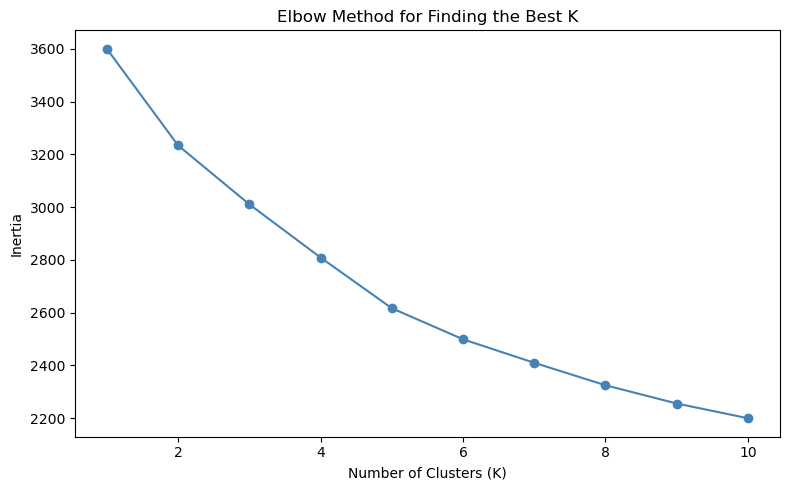

    K      Inertia
0   1  3600.000000
1   2  3233.946110
2   3  3010.728969
3   4  2809.060626
4   5  2616.900632
5   6  2499.169348
6   7  2410.072349
7   8  2325.025743
8   9  2255.820535
9  10  2199.952364


In [14]:
# Task 3: Apply K-means Clustering

#Step 1: Elbow Method to find the best K

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', color='steelblue')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Finding the Best K")
plt.tight_layout()
plt.savefig("elbow_plot.png", dpi=150)
plt.show()

elbow_df = pd.DataFrame({"K": list(K_range), "Inertia": inertia})
print(elbow_df)

In [16]:
# Step 2: Select number of clusters based on Elbow Method

print("Selected number of clusters: K = 3")
print("Reason: The elbow point in the inertia graph appears at K = 3.")
print("Adding more clusters after K = 3 does not significantly reduce inertia.")

Selected number of clusters: K = 3
Reason: The elbow point in the inertia graph appears at K = 3.
Adding more clusters after K = 3 does not significantly reduce inertia.


In [17]:
# Step 3: Train the final K-means model

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

print("Cluster Labels (first 10):", cluster_labels[:10])

print("\nNumber of purchase orders in each cluster:")
print(pd.Series(cluster_labels).value_counts().sort_index())

Cluster Labels (first 10): [0 2 1 0 2 2 0 0 0 0]

Number of purchase orders in each cluster:
0    125
1     96
2    139
Name: count, dtype: int64


C:\Users\nnish\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [18]:
# Step 4: Add cluster labels back to the dataset

df_clustered = df_clean.copy()
df_clustered["Cluster"] = cluster_labels

print("Dataset with Cluster Labels:")
print(df_clustered.head())

print("\nCluster Distribution:")
print(df_clustered["Cluster"].value_counts().sort_index())

Dataset with Cluster Labels:
     Supplier_Category   Supplier_Region     Contract_Type     Shipping_Mode  \
0   Breakroom Supplies  British Columbia      New Supplier     Local Courier   
1       IT Accessories           Alberta   Approved Vendor  Expedited Ground   
2  Packaging Materials           Ontario  Preferred Vendor       Air Freight   
3    Printing Supplies        US Midwest      New Supplier   Standard Ground   
4   Breakroom Supplies            Quebec  Preferred Vendor   Standard Ground   

  Payment_Terms  Seasonal_Period  Order_Value_CAD  Number_of_Line_Items  \
0       Prepaid          Regular          4214.00                    12   
1        Net 30  Fiscal Year End          6895.44                    12   
2        Net 30     Holiday Rush          3890.34                     7   
3       Prepaid     Holiday Rush         10486.43                     2   
4        Net 30          Regular          4255.70                     2   

   Promised_Lead_Time_Days  Past_On_Tim

In [19]:
# Task 4: Analyze and Interpret the Clusters

# Step 1: Calculate cluster summary
cluster_summary = df_clustered.groupby("Cluster")[numerical_columns].mean().round(2)
print("Cluster Summary (Average Values):")
print(cluster_summary)

Cluster Summary (Average Values):
         Order_Value_CAD  Number_of_Line_Items  Promised_Lead_Time_Days  \
Cluster                                                                   
0                5929.13                  7.03                     9.59   
1                5345.34                  6.46                    13.23   
2                6193.21                  6.37                     9.22   

         Past_On_Time_Rate  Supplier_Rating  Quality_Incidents_Last_6M  \
Cluster                                                                  
0                     0.71             3.15                       0.76   
1                     0.83             3.99                       1.70   
2                     0.88             4.22                       0.37   

         Prior_Delays_Last_6M  Distance_KM  Inventory_Buffer_Days  \
Cluster                                                             
0                        1.10       627.02                  17.44   
1           

In [20]:
# Step 2: Add customer counts

cluster_counts = df_clustered["Cluster"].value_counts().sort_index()
cluster_summary["Number_of_Orders"] = cluster_counts
print("\nCluster Summary with Order Counts:")
print(cluster_summary)


Cluster Summary with Order Counts:
         Order_Value_CAD  Number_of_Line_Items  Promised_Lead_Time_Days  \
Cluster                                                                   
0                5929.13                  7.03                     9.59   
1                5345.34                  6.46                    13.23   
2                6193.21                  6.37                     9.22   

         Past_On_Time_Rate  Supplier_Rating  Quality_Incidents_Last_6M  \
Cluster                                                                  
0                     0.71             3.15                       0.76   
1                     0.83             3.99                       1.70   
2                     0.88             4.22                       0.37   

         Prior_Delays_Last_6M  Distance_KM  Inventory_Buffer_Days  \
Cluster                                                             
0                        1.10       627.02                  17.44   
1         

In [21]:
# Step 3: Identify and name segments based on characteristics

summary = cluster_summary.copy()

high_risk_cluster    = summary["Prior_Delays_Last_6M"].idxmax()
remaining            = summary.drop(index=high_risk_cluster)
low_risk_cluster     = remaining["Past_On_Time_Rate"].idxmax()
medium_risk_cluster  = summary.drop(index=[high_risk_cluster, low_risk_cluster]).index[0]

segment_names = {
    high_risk_cluster:   "High Delay Risk Suppliers",
    medium_risk_cluster: "Moderate Risk Suppliers",
    low_risk_cluster:    "Low Risk Reliable Suppliers"
}

df_clustered["Segment_Name"] = df_clustered["Cluster"].map(segment_names)

print("Segment Distribution:")
print(df_clustered["Segment_Name"].value_counts())

print("\nFirst 5 rows with Segment Names:")
print(df_clustered[["Cluster", "Segment_Name"]].head())

Segment Distribution:
Segment_Name
Low Risk Reliable Suppliers    139
Moderate Risk Suppliers        125
High Delay Risk Suppliers       96
Name: count, dtype: int64

First 5 rows with Segment Names:
   Cluster                 Segment_Name
0        0      Moderate Risk Suppliers
1        2  Low Risk Reliable Suppliers
2        1    High Delay Risk Suppliers
3        0      Moderate Risk Suppliers
4        2  Low Risk Reliable Suppliers


In [22]:
# Step 4: Interpretation table

interpretation = pd.DataFrame({
    "Segment Name": list(segment_names.values()),
    "Main Characteristics": [
        "High prior delays, low on-time rate, frequent quality incidents",
        "Moderate delays, average on-time rate, medium supplier rating",
        "Low prior delays, high on-time rate, strong supplier rating"
    ],
    "Recommended Strategy": [
        "Assign backup suppliers, increase inventory buffer, send early reminders",
        "Monitor closely, send proactive reminders, review shipping mode",
        "Maintain relationship, offer preferred contract terms, use as benchmark"
    ]
})

print(interpretation.to_string(index=False))

               Segment Name                                            Main Characteristics                                                     Recommended Strategy
  High Delay Risk Suppliers High prior delays, low on-time rate, frequent quality incidents Assign backup suppliers, increase inventory buffer, send early reminders
    Moderate Risk Suppliers   Moderate delays, average on-time rate, medium supplier rating          Monitor closely, send proactive reminders, review shipping mode
Low Risk Reliable Suppliers     Low prior delays, high on-time rate, strong supplier rating  Maintain relationship, offer preferred contract terms, use as benchmark


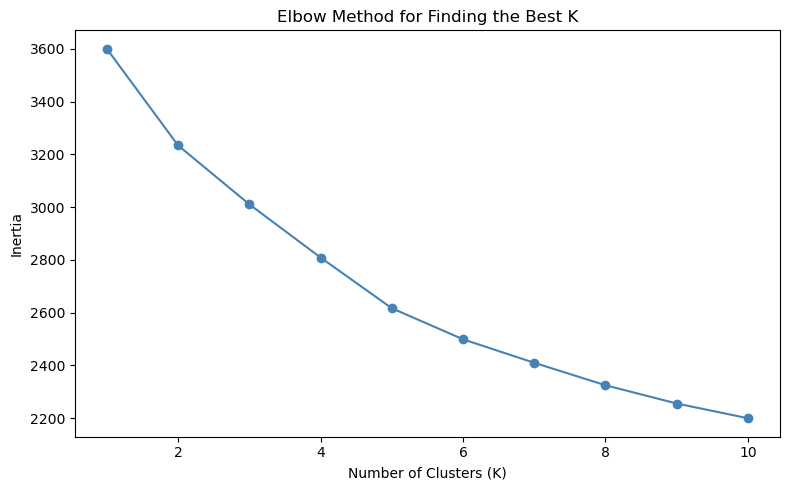


Analysis:
The Elbow Method graph shows how inertia decreases as the number of clusters increases.
From K=1 to K=3 the inertia drops sharply, meaning adding clusters significantly
improves the grouping. After K=3 the decrease becomes much slower.
The elbow point at K=3 indicates that 3 clusters is the most suitable choice.



In [23]:
# Task 5: Visualize the Clusters

# Visualization 1: Elbow Method 

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', color='steelblue')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Finding the Best K")
plt.tight_layout()
plt.show()

print("""
Analysis:
The Elbow Method graph shows how inertia decreases as the number of clusters increases.
From K=1 to K=3 the inertia drops sharply, meaning adding clusters significantly
improves the grouping. After K=3 the decrease becomes much slower.
The elbow point at K=3 indicates that 3 clusters is the most suitable choice.
""")

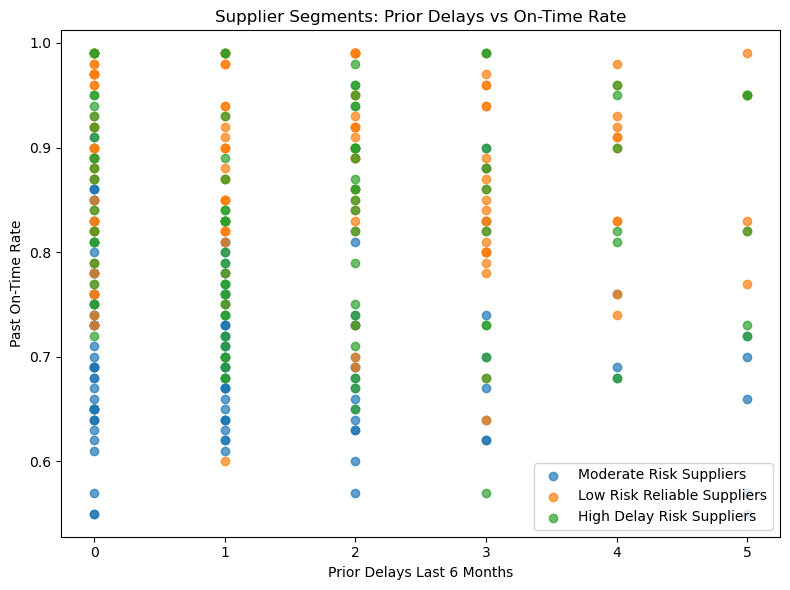


Analysis:
This scatter plot shows how the three supplier segments are distributed based on
Prior Delays Last 6 Months and Past On-Time Rate. High Delay Risk Suppliers
appear in the upper-left area with more delays and lower on-time rates.
Low Risk Reliable Suppliers appear in the lower-right with fewer delays and
higher on-time rates. Moderate Risk Suppliers sit between the two groups.
The clear separation between segments confirms that the clustering model
identified meaningful patterns in supplier behaviour.



In [24]:
# Visualization 2: Scatter Plot 

plt.figure(figsize=(8, 6))
for segment in df_clustered["Segment_Name"].unique():
    segment_data = df_clustered[df_clustered["Segment_Name"] == segment]
    plt.scatter(
        segment_data["Prior_Delays_Last_6M"],
        segment_data["Past_On_Time_Rate"],
        label=segment,
        alpha=0.7
    )

plt.xlabel("Prior Delays Last 6 Months")
plt.ylabel("Past On-Time Rate")
plt.title("Supplier Segments: Prior Delays vs On-Time Rate")
plt.legend()
plt.tight_layout()
plt.savefig("scatter_plot.png", dpi=150)
plt.show()

print("""
Analysis:
This scatter plot shows how the three supplier segments are distributed based on
Prior Delays Last 6 Months and Past On-Time Rate. High Delay Risk Suppliers
appear in the upper-left area with more delays and lower on-time rates.
Low Risk Reliable Suppliers appear in the lower-right with fewer delays and
higher on-time rates. Moderate Risk Suppliers sit between the two groups.
The clear separation between segments confirms that the clustering model
identified meaningful patterns in supplier behaviour.
""")

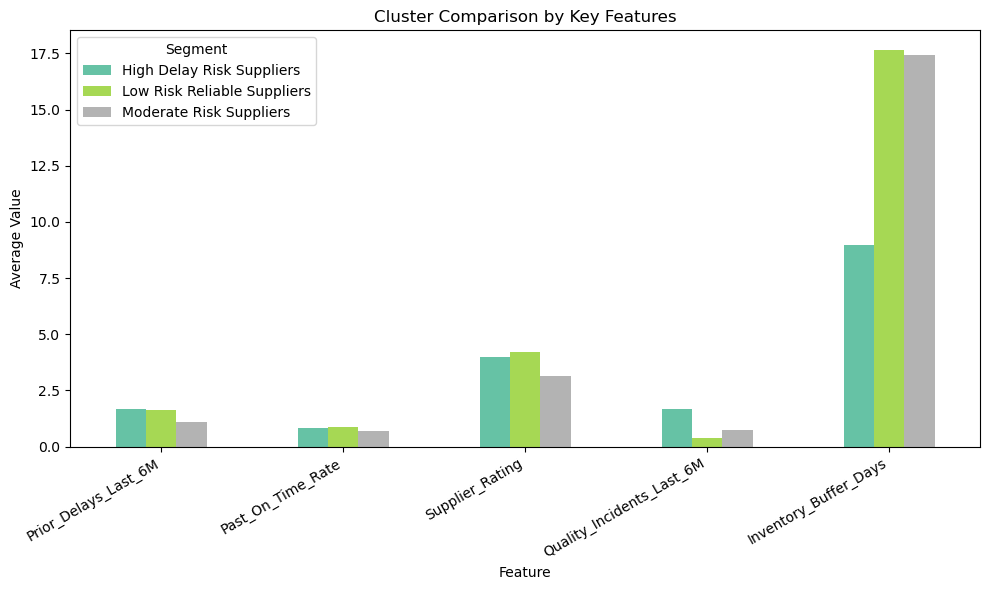


Analysis:
This bar chart compares the three supplier segments across key features.
High Delay Risk Suppliers have the highest prior delays and quality incidents
and the lowest past on-time rate. Low Risk Reliable Suppliers show the
opposite pattern with fewer delays and higher supplier ratings.
Moderate Risk Suppliers fall between the two extremes.
These differences confirm that each segment has a distinct risk profile
that ProcurePro can use to design targeted procurement strategies.



In [25]:
# Visualization 3: Bar Chart comparing cluster averages

key_features = ['Prior_Delays_Last_6M', 'Past_On_Time_Rate',
                'Supplier_Rating', 'Quality_Incidents_Last_6M',
                'Inventory_Buffer_Days']

cluster_avg = df_clustered.groupby("Segment_Name")[key_features].mean()

cluster_avg.T.plot(kind='bar', figsize=(10, 6), colormap='Set2')
plt.title("Cluster Comparison by Key Features")
plt.xlabel("Feature")
plt.ylabel("Average Value")
plt.xticks(rotation=30, ha='right')
plt.legend(title="Segment")
plt.tight_layout()
plt.savefig("bar_chart.png", dpi=150)
plt.show()

print("""
Analysis:
This bar chart compares the three supplier segments across key features.
High Delay Risk Suppliers have the highest prior delays and quality incidents
and the lowest past on-time rate. Low Risk Reliable Suppliers show the
opposite pattern with fewer delays and higher supplier ratings.
Moderate Risk Suppliers fall between the two extremes.
These differences confirm that each segment has a distinct risk profile
that ProcurePro can use to design targeted procurement strategies.
""")

PCA1 Explained Variance: 0.1432
PCA2 Explained Variance: 0.1320
Total Explained Variance: 0.2752


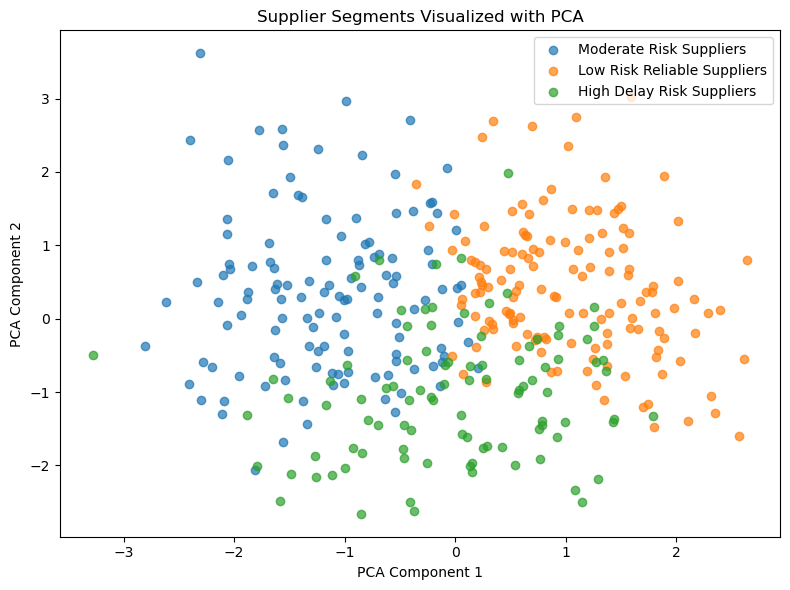


Analysis:
This PCA visualization reduces all ten features into two components to display
the supplier segments in a two-dimensional space. The three segments are
clearly separated from each other, confirming that the K-means model
successfully identified distinct supplier groups based on their
order characteristics and performance history.



In [26]:
# Visualization 4: PCA Plot

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_clustered["PCA1"] = X_pca[:, 0]
df_clustered["PCA2"] = X_pca[:, 1]

explained = pca.explained_variance_ratio_
print(f"PCA1 Explained Variance: {explained[0]:.4f}")
print(f"PCA2 Explained Variance: {explained[1]:.4f}")
print(f"Total Explained Variance: {explained.sum():.4f}")

plt.figure(figsize=(8, 6))
for segment in df_clustered["Segment_Name"].unique():
    segment_data = df_clustered[df_clustered["Segment_Name"] == segment]
    plt.scatter(segment_data["PCA1"], segment_data["PCA2"], label=segment, alpha=0.7)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Supplier Segments Visualized with PCA")
plt.legend()
plt.tight_layout()
plt.savefig("pca_plot.png", dpi=150)
plt.show()

print("""
Analysis:
This PCA visualization reduces all ten features into two components to display
the supplier segments in a two-dimensional space. The three segments are
clearly separated from each other, confirming that the K-means model
successfully identified distinct supplier groups based on their
order characteristics and performance history.
""")

In [28]:
# Task 6: Business Interpretation

print("""
Task 6: Business Interpretation

1. What patterns did you discover?
Three distinct supplier segments were discovered. The first group is High Delay Risk Suppliers, which have high prior delays, frequent quality incidents, and low on-time rates. The second group is Moderate Risk Suppliers, which show average performance across all features. The third group is Low Risk Reliable Suppliers, which have low delay history, high on-time rates, and strong supplier ratings.

2. How can the business use these segments?
ProcurePro can use these segments to prioritize procurement resources. High Delay Risk Suppliers should receive immediate attention with backup supplier arrangements, increased inventory buffers, and early communication before order deadlines. Moderate Risk Suppliers should be monitored closely and receive proactive reminders. Low Risk Reliable Suppliers can be rewarded with preferred contract terms and used as benchmark suppliers.

3. What marketing strategy would you suggest for each segment?
-High Delay Risk Suppliers: Assign dedicated account managers, require more frequent status updates, prepare alternative shipping arrangements, and increase inventory buffer days for orders from this group.
-Moderate Risk Suppliers: Send proactive reminders at key delivery milestones, review shipping modes and payment terms, and offer performance improvement incentives to move them toward the low-risk group.
-Low Risk Reliable Suppliers: Maintain the relationship through preferred contract terms, volume commitments, and recognition programs. Use their performance data as a benchmark for other suppliers.

4. How can this analysis help the business improve decision-making?
This analysis helps ProcurePro move from reactive to proactive procurement management. Instead of waiting for delays to happen, the business can use segment information to take early action on high-risk orders. It also helps managers allocate attention more efficiently by focusing on the suppliers and orders that need it most.

""")


Task 6: Business Interpretation

1. What patterns did you discover?
Three distinct supplier segments were discovered. The first group is High Delay Risk Suppliers, which have high prior delays, frequent quality incidents, and low on-time rates. The second group is Moderate Risk Suppliers, which show average performance across all features. The third group is Low Risk Reliable Suppliers, which have low delay history, high on-time rates, and strong supplier ratings.

2. How can the business use these segments?
ProcurePro can use these segments to prioritize procurement resources. High Delay Risk Suppliers should receive immediate attention with backup supplier arrangements, increased inventory buffers, and early communication before order deadlines. Moderate Risk Suppliers should be monitored closely and receive proactive reminders. Low Risk Reliable Suppliers can be rewarded with preferred contract terms and used as benchmark suppliers.

3. What marketing strategy would you suggest for

In [1]:
# Task 7: Limitations and Responsible AI Reflection

print("""
Task 7: Limitations and Responsible AI Reflection

1. What is one limitation of your dataset or clustering model?
The dataset is synthetic and does not reflect real-world procurement complexity. Factors such as weather disruptions, supplier strikes, sudden demand changes, customs delays, and new supplier improvements are not captured in the data. This means the clusters may not fully represent real supplier behaviour.

2. Why does K-means not always produce perfect customer segments?
K-means requires the number of clusters to be chosen before training, which is not always obvious from the data. It also assumes clusters are roughly circular and equally sized, which may not match real supplier patterns. K-means is sensitive to outliers and may group unusual orders incorrectly. Different random starting points can also produce slightly different results.

3. What kind of bias or unfair decision could happen if the business uses these clusters without human review?
The model may unfairly associate certain supplier regions or categories with high delay risk based on historical patterns that no longer apply. For example, a supplier from a region that previously had delays may have improved significantly but still be flagged as high risk. Using the model without review could damage supplier relationships, lead to unfair contract decisions, or result in missed opportunities with improving suppliers.

4. Why should human judgment still be used when making marketing decisions?
The model is a decision-support tool, not a replacement for human expertise. Procurement managers understand supplier relationships, current market conditions, contract obligations, and customer priorities that are not captured in the data. Human review ensures that model predictions are interpreted in context and that suppliers are treated fairly. Final decisions about supplier actions should always involve both data-driven insights and professional judgment.

""")   


Task 7: Limitations and Responsible AI Reflection

1. What is one limitation of your dataset or clustering model?
The dataset is synthetic and does not reflect real-world procurement complexity. Factors such as weather disruptions, supplier strikes, sudden demand changes, customs delays, and new supplier improvements are not captured in the data. This means the clusters may not fully represent real supplier behaviour.

2. Why does K-means not always produce perfect customer segments?
K-means requires the number of clusters to be chosen before training, which is not always obvious from the data. It also assumes clusters are roughly circular and equally sized, which may not match real supplier patterns. K-means is sensitive to outliers and may group unusual orders incorrectly. Different random starting points can also produce slightly different results.

3. What kind of bias or unfair decision could happen if the business uses these clusters without human review?
The model may unfairly 